# **IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import shap

# **LOAD DATASET & DATASET INFO**

In [ ]:
df = pd.read_csv('UCI_Credit_Card.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [ ]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


# **Exploratory Data Analysis (EDA)**

**Objective:**

To understand the **distribution of default events**, **customer repayment behavior**,
and **credit exposure patterns** in order to guide preprocessing, feature engineering, and modeling decisions.

**1. Target Variable Analysis**
---

In [ ]:
df['default.payment.next.month'].value_counts()

,count
default.payment.next.month,
0,23364
1,6636


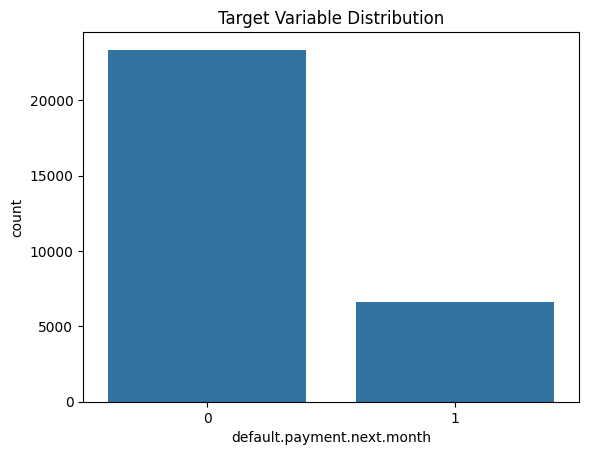

In [ ]:
plt.title("Target Variable Distribution")
sns.countplot(df, x='default.payment.next.month')
plt.show()
# df['default.payment.next.month'].value_counts().plot(kind='bar')

In [ ]:
value_counts = df['default.payment.next.month'].value_counts()
count_0 = value_counts[0]
count_1 = value_counts[1]
total_count = count_0 + count_1

print(f"Non-Default Rate = {((count_0/total_count)*100):.2f}%")
print(f"Default Rate = {((count_1/total_count)*100):.2f}%")

Non-Default Rate = 77.88%
Default Rate = 22.12%


**Conclusion:**

Default events are relatively rare, the dataset is naturally **imbalanced**, which reflects real-world credit risk scenarios.

**2. Repayment Status Analysis**
---

Distribution of PAY_0 (Repayment status in September 2005)
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64



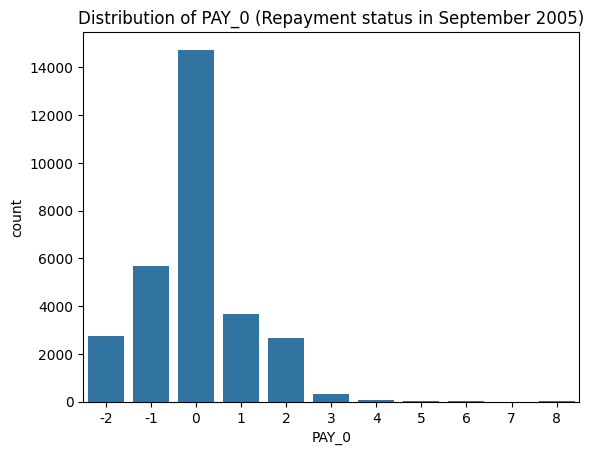


Distribution of PAY_2 (Repayment status in August 2005)
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64



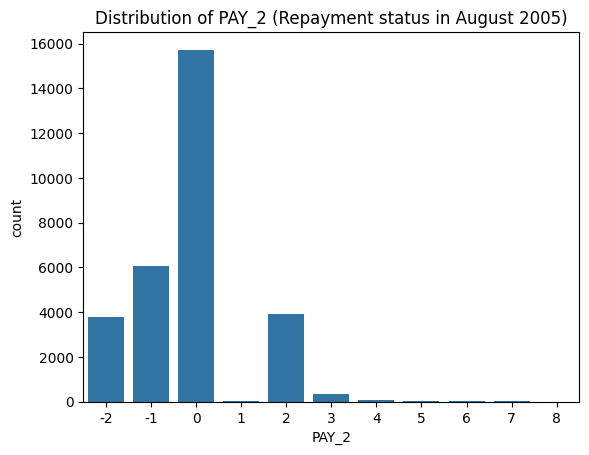


Distribution of PAY_3 (Repayment status in July 2005)
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64



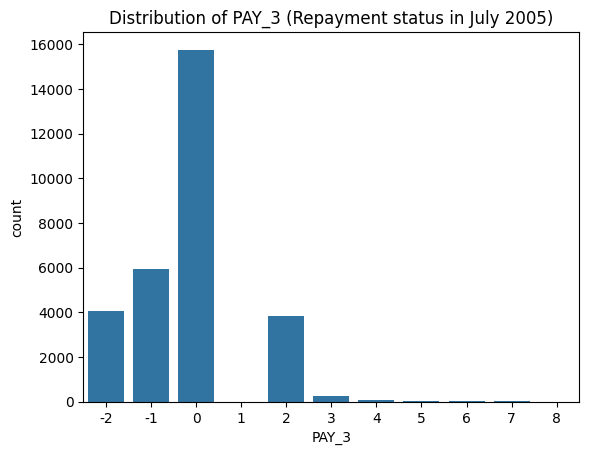


Distribution of PAY_4 (Repayment status in June 2005)
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64



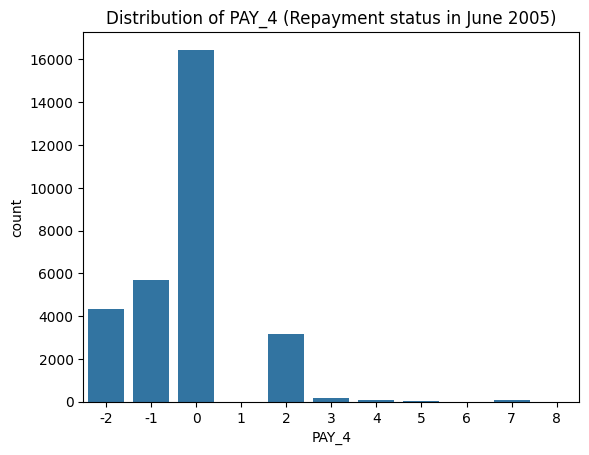


Distribution of PAY_5 (Repayment status in May 2005)
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64



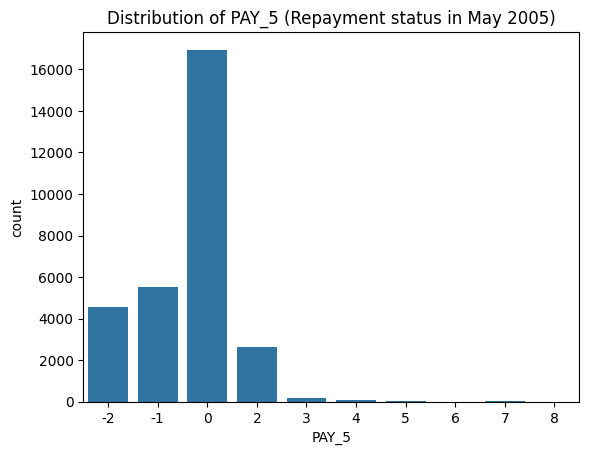


Distribution of PAY_6 (Repayment status in April 2005)
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64



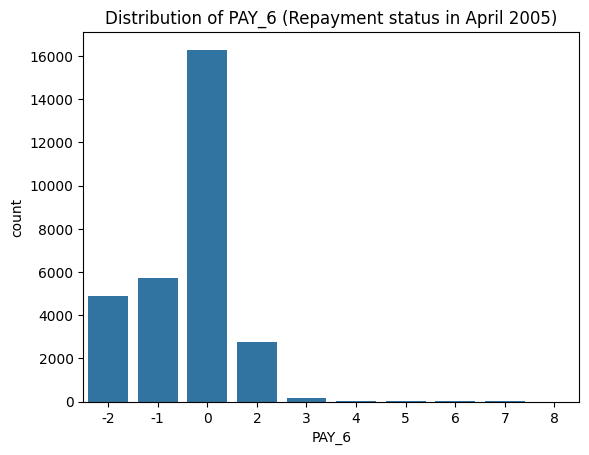

In [ ]:
# Distribution of each Repayment Status
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

descriptions = [
    'Repayment status in September 2005',
    'Repayment status in August 2005',
    'Repayment status in July 2005',
    'Repayment status in June 2005',
    'Repayment status in May 2005',
    'Repayment status in April 2005'
]

target_col = 'default.payment.next.month'

for col, desc in zip(pay_cols, descriptions):
  print(f"Distribution of {col} ({desc})")
  print(f"{df[col].value_counts().sort_index()}\n")
  sns.countplot(df, x=col)
  plt.title(f'Distribution of {col} ({desc})')
  plt.show()
  print("")

In [ ]:
# Repayment Status vs Default
for col in pay_cols:
  ct = pd.crosstab(df[col], df[target_col], normalize='index')
  print(f"Default rate by {col}:")
  print(ct)
  print("")

Default rate by PAY_0:
default.payment.next.month         0         1
PAY_0                                         
-2                          0.867706  0.132294
-1                          0.832219  0.167781
 0                          0.871887  0.128113
 1                          0.660521  0.339479
 2                          0.308586  0.691414
 3                          0.242236  0.757764
 4                          0.315789  0.684211
 5                          0.500000  0.500000
 6                          0.454545  0.545455
 7                          0.222222  0.777778
 8                          0.421053  0.578947

Default rate by PAY_2:
default.payment.next.month         0         1
PAY_2                                         
-2                          0.817292  0.182708
-1                          0.840331  0.159669
 0                          0.840877  0.159123
 1                          0.821429  0.178571
 2                          0.443850  0.556150
 3           

**Conclusion:**

The analysis of repayment status variables (PAY_0 – PAY_6) reveals a **strong and consistent relationship between historical payment behavior and credit default risk**. Customers with **delayed payments (PAY_X ≥ 1)** show significantly **higher default rates** compared to those who paid duly (-1) or maintained revolving credit (0).

**3. Billing Amount Analysis**
---

In [ ]:
# Distribution of each Bill Amount
bill_cols = [
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6'
]

descriptions = [
    'Amount of bill statement in September 2005',
    'Amount of bill statement in August 2005',
    'Amount of bill statement in July 2005',
    'Amount of bill statement in June 2005',
    'Amount of bill statement in May 2005',
    'Amount of bill statement in April 2005'
]

df[bill_cols].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400
std,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000
50%,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000
75%,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


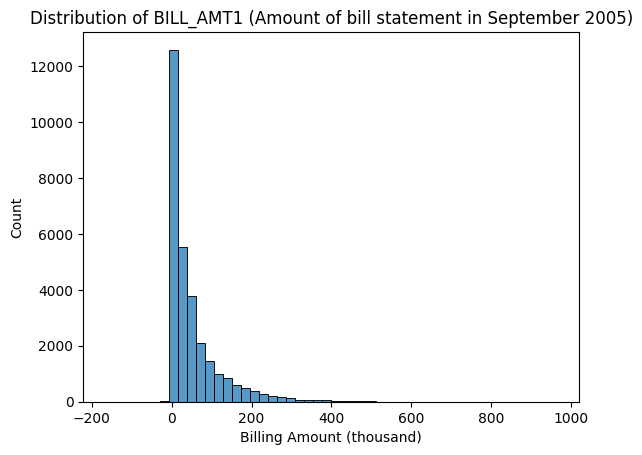

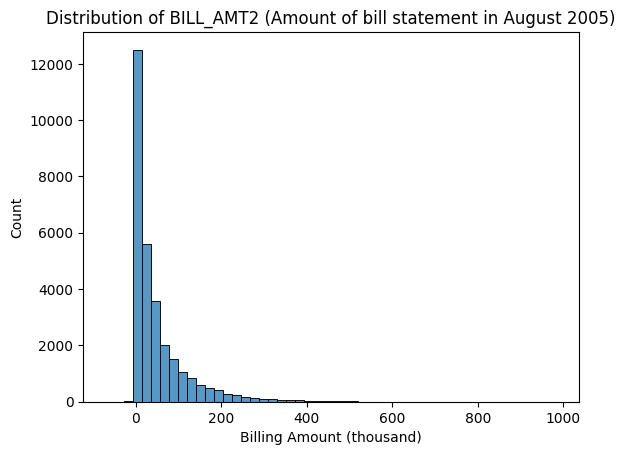

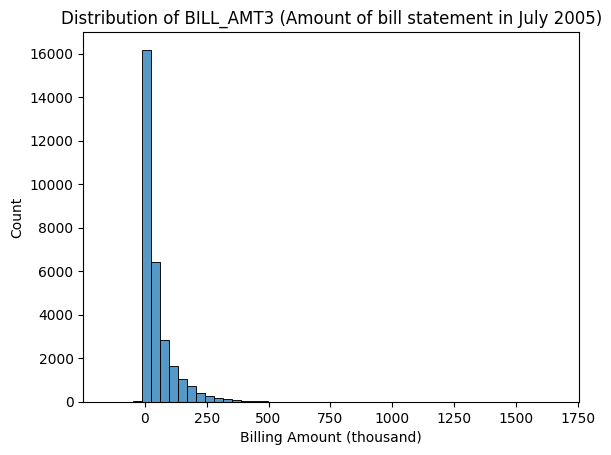

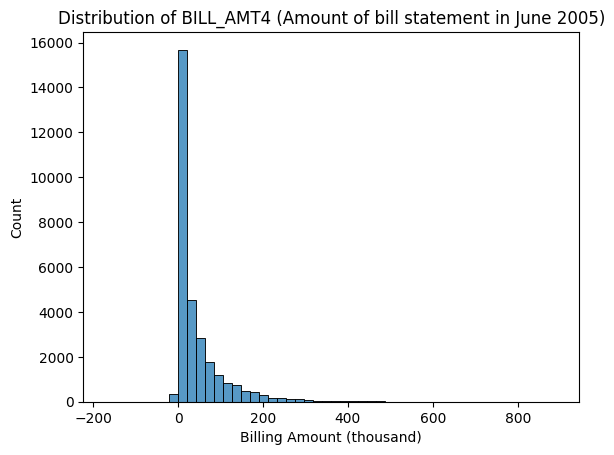

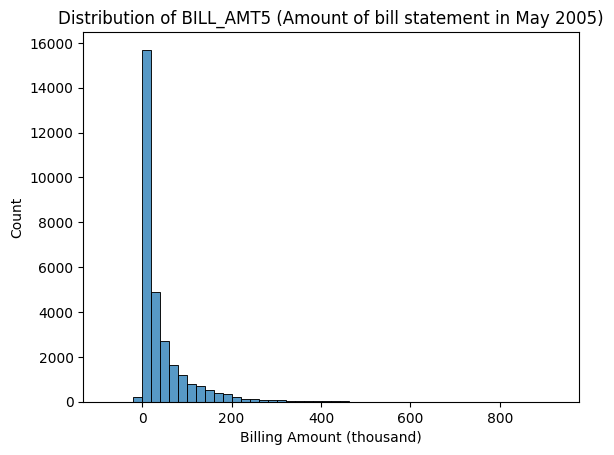

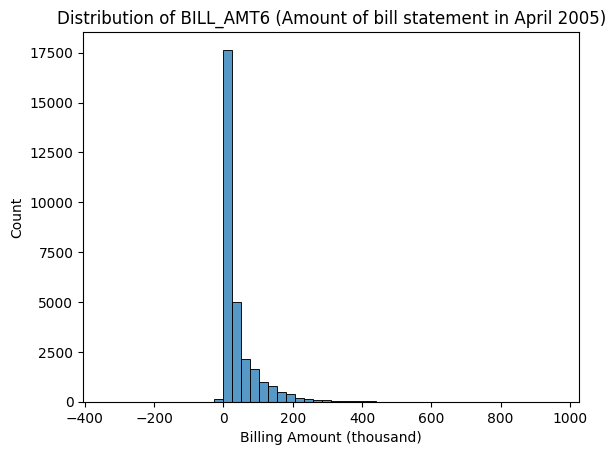

In [ ]:
for col, desc in zip(bill_cols, descriptions):
  sns.histplot(df[col] / 1000, bins=50)
  plt.title(f'Distribution of {col} ({desc})')
  plt.xlabel('Billing Amount (thousand)')
  plt.ylabel('Count')
  plt.show()
  print("")

In [ ]:
# Billing Amount vs Default
df.groupby(target_col)[bill_cols].agg(['mean', 'median'])

BILL_AMT1              BILL_AMT2           \
                                    mean   median          mean   median   
default.payment.next.month                                                 
0                           51994.227273  23119.5  49717.435670  21660.5   
1                           48509.162297  20185.0  47283.617842  20300.5   

                               BILL_AMT3              BILL_AMT4           \
                                    mean   median          mean   median   
default.payment.next.month                                                 
0                           47533.365605  20202.5  43611.165254  19000.0   
1                           45181.598855  19834.5  42036.950573  19119.5   

                               BILL_AMT5              BILL_AMT6           
                                    mean   median          mean   median  
default.payment.next.month                                                
0                           40530.445343  17998.0  39042.268704  16679.0  
1                           39540.190476  18478.5  38271.435503  18028.5

**Conclusion:**

The analysis of billing amount variables (BILL_AMT1 – BILL_AMT6) indicates that **outstanding balances alone do not strongly drive credit default risk**. Across all observed months, customers who **default consistently exhibit lower average and median billing amounts compared to non-default customers**. This pattern suggests that default events are not primarily triggered by large outstanding bills, but rather reflect prior credit risk management actions, where customers with deteriorating repayment behavior experience reduced credit exposure before default occurs. Consequently, billing amounts should be interpreted in conjunction with repayment behavior and payment adequacy rather than as standalone indicators of default risk.

**4. Payment Amount Analysis**
---

In [ ]:
# Distribution of each Payment Amount
pay_amount_cols = [
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

descriptions = [
    'Amount of previous payment in September 2005',
    'Amount of previous payment in August 2005',
    'Amount of previous payment in July 2005',
    'Amount of previous payment in June 2005',
    'Amount of previous payment in May 2005',
    'Amount of previous payment in April 2005'
]

df[pay_amount_cols].describe()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


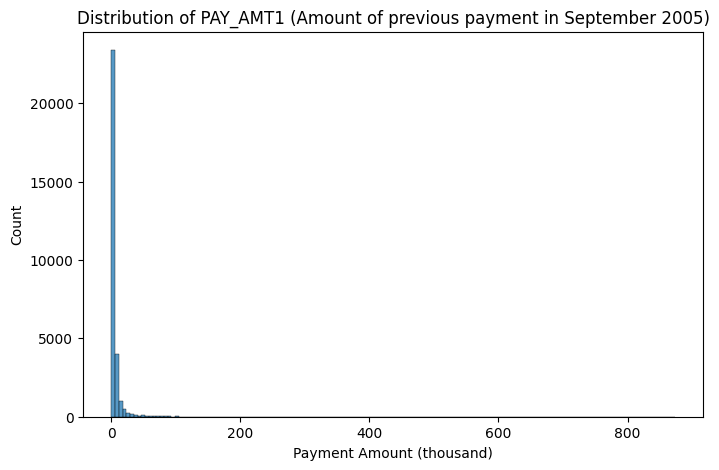

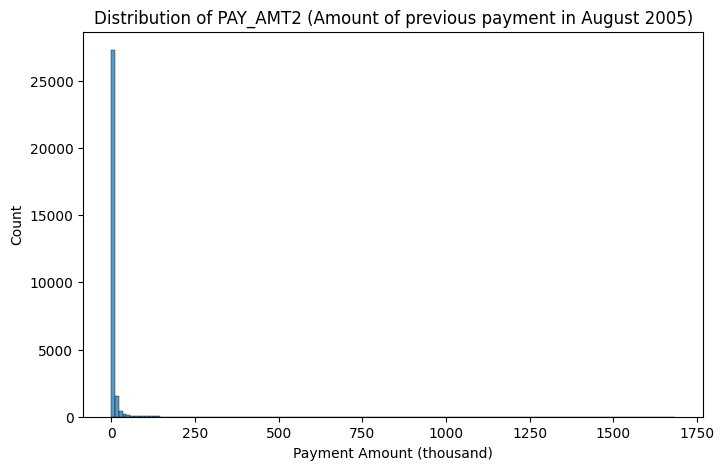

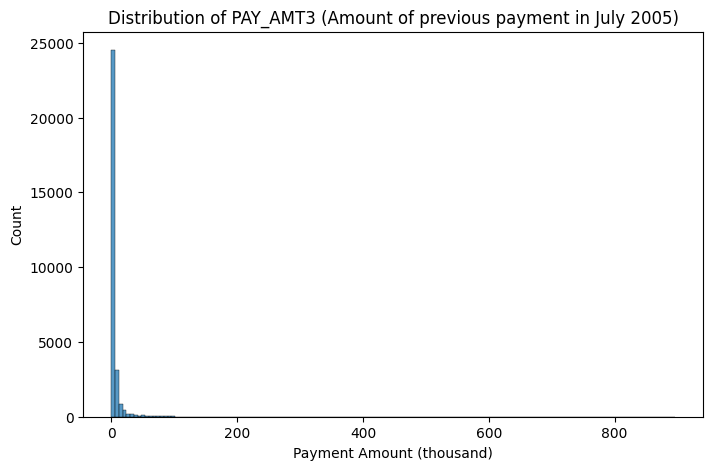

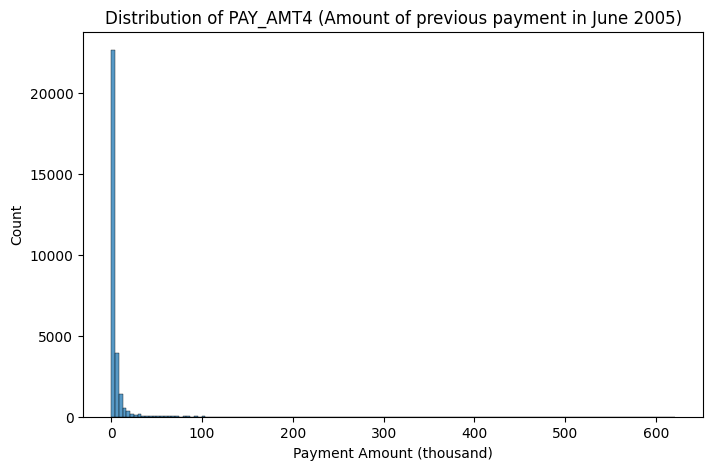

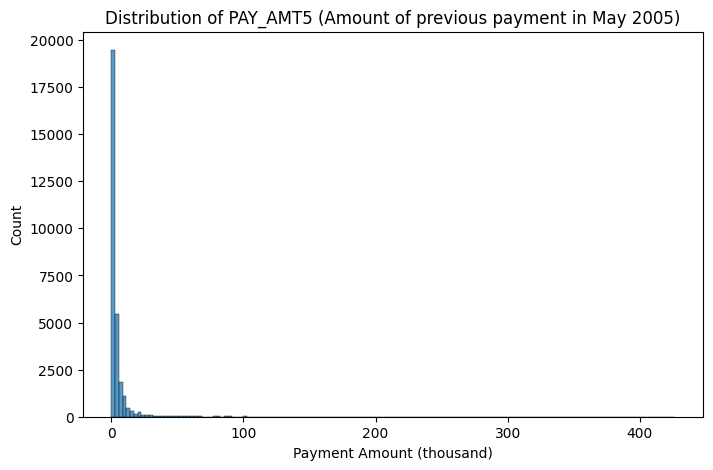

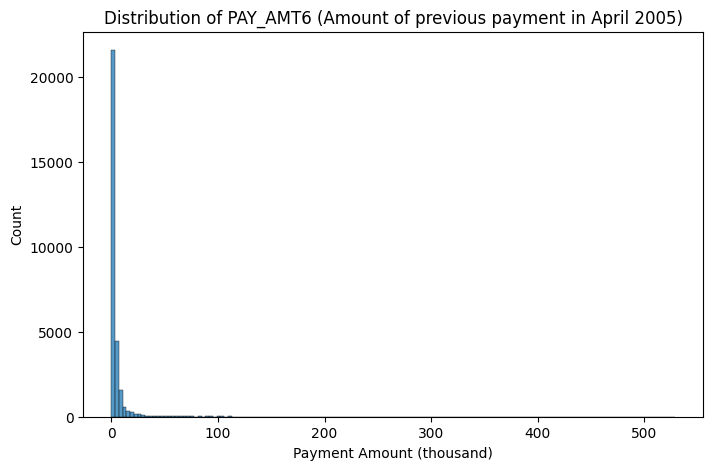

In [ ]:
for col, desc in zip(pay_amount_cols, descriptions):
  plt.figure(figsize=(8, 5))
  sns.histplot(df[col] / 1000, bins=150)
  plt.title(f"Distribution of {col} ({desc})")
  plt.xlabel("Payment Amount (thousand)")
  plt.show()
  print("")

In [ ]:
# Payment Amount vs Default
df.groupby(target_col)[pay_amount_cols].agg(['mean', 'median'])

PAY_AMT1             PAY_AMT2          \
                                   mean  median         mean  median   
default.payment.next.month                                             
0                           6307.337357  2459.5  6640.465074  2247.5   
1                           3397.044153  1636.0  3388.649638  1533.5   

                               PAY_AMT3             PAY_AMT4          \
                                   mean  median         mean  median   
default.payment.next.month                                             
0                           5753.496833  2000.0  5300.529319  1734.0   
1                           3367.351567  1222.0  3155.626733  1000.0   

                               PAY_AMT5             PAY_AMT6          
                                   mean  median         mean  median  
default.payment.next.month                                            
0                           5248.220296  1765.0  5719.371769  1706.0  
1                           3219.139542  1000.0  3441.482068  1000.0

**Conclusion:**

The analysis of payment amount variables (PAY_AMT1 – PAY_AMT6) reveals a **strong and consistent relationship between payment behavior and credit default risk**. **Default customers** exhibit significantly **lower payment amounts** across all observed months. In contrast, **non-default customers** demonstrate **higher and more stable payment patterns**. This highlights that **default risk is primarily driven by insufficient repayment behavior** rather than the absolute size of outstanding bill amount.

Although higher outstanding balances can make repayment more difficult in theory, the observed results indicate that default risk in this dataset is mainly driven by insufficient payment behavior. This likely reflects credit control measures, where customers with higher risk are given lower credit exposure before default occurs.

**5. Payment-to-Bill Ratio Analysis**
---

In [ ]:
# Compute Payment-to-Bill ratio
for i in range(len(pay_amount_cols)):
  bill = df[bill_cols[i]]
  payment = df[pay_amount_cols[i]]
  df[f'PAY_BILL_RATIO_{i+1}'] = np.where(
      bill > 0,
      payment / bill,
      0
  )

In [ ]:
df[['PAY_AMT1','BILL_AMT1','PAY_BILL_RATIO_1']].head(10)

,PAY_AMT1,BILL_AMT1,PAY_BILL_RATIO_1
0,0.0,3913.0,0.000000
1,0.0,2682.0,0.000000
2,1518.0,29239.0,0.051917
3,2000.0,46990.0,0.042562
4,2000.0,8617.0,0.232099
5,2500.0,64400.0,0.038820
6,55000.0,367965.0,0.149471
7,380.0,11876.0,0.031997
8,3329.0,11285.0,0.294993
9,0.0,0.0,0.000000


In [ ]:
# Payment-to-Bill Ratio vs Default
ratio_cols = [f'PAY_BILL_RATIO_{i+1}' for i in range(6)]

df.groupby(target_col)[ratio_cols].median()

,PAY_BILL_RATIO_1,PAY_BILL_RATIO_2,PAY_BILL_RATIO_3,PAY_BILL_RATIO_4,PAY_BILL_RATIO_5,PAY_BILL_RATIO_6
default.payment.next.month,,,,,,
0,0.05562,0.053204,0.043697,0.038724,0.041139,0.040533
1,0.04585,0.044048,0.036851,0.036460,0.037275,0.037057


**Conclusion:**

The payment-to-bill ratio analysis shows a **strong relationship between how much customers pay relative to their bills and default risk**. **Default customers** consistently have **lower payment-to-bill ratios**, meaning they regularly pay less compared to what they owe. In contrast, **non-default customers** show **higher and more stable ratios**, indicating better repayment behavior. This suggests that default risk is mainly driven by **insufficient repayments rather than the amount of the bill itself**.

Although the absolute ratio values are small due to revolving credit behavior and partial payments, the **stable gap** between the two groups highlights how much customers pay relative to their bills as a strong behavioral indicator of default risk.

# **FEATURE ENGINEERING**

**Objective:**

Feature engineering is performed to transform **raw monthly credit card data into aggregated behavioral indicators that better capture long-term repayment patterns**. These engineered features reduce noise, improve model performance, and enhance interpretability by summarizing customer behavior in a way that aligns with real-world credit risk assessment.

**1. Billing Amount Aggregates**
---

Billing amount aggregates are created to **summarize customers’ overall bill amount across multiple months**. By using average and maximum billing amounts, the model could capture both typical and peak bill amount while reducing noise from monthly fluctuations.

In [ ]:
df['AVG_BILL_AMT'] = df[bill_cols].mean(axis=1)
df['MAX_BILL_AMT'] = df[bill_cols].max(axis=1)

In [ ]:
df[['ID', 'AVG_BILL_AMT', 'MAX_BILL_AMT']].head(10)

,ID,AVG_BILL_AMT,MAX_BILL_AMT
0,1,1284.000000,3913.0
1,2,2846.166667,3455.0
2,3,16942.166667,29239.0
3,4,38555.666667,49291.0
4,5,18223.166667,35835.0
5,6,39685.666667,64400.0
6,7,454099.166667,542653.0
7,8,2247.666667,11876.0
8,9,10868.666667,14096.0
9,10,4486.500000,13912.0


**2. Payment Amount Aggregates**
---

Payment amount aggregates are created to capture customers’ **overall payment amount across multiple months**. By using average and maximum payment amounts, the model could summarize repayment consistency and capacity while reducing noise from monthly fluctuations.

In [ ]:
df['AVG_PAY_AMT'] = df[pay_amount_cols].mean(axis=1)
df['MAX_PAY_AMT'] = df[pay_amount_cols].max(axis=1)

In [ ]:
df[['ID', 'AVG_BILL_AMT', 'MAX_BILL_AMT', 'AVG_PAY_AMT', 'MAX_PAY_AMT']].head(10)

,ID,AVG_BILL_AMT,MAX_BILL_AMT,AVG_PAY_AMT,MAX_PAY_AMT
0,1,1284.000000,3913.0,114.833333,689.0
1,2,2846.166667,3455.0,833.333333,2000.0
2,3,16942.166667,29239.0,1836.333333,5000.0
3,4,38555.666667,49291.0,1398.000000,2019.0
4,5,18223.166667,35835.0,9841.500000,36681.0
5,6,39685.666667,64400.0,1295.333333,2500.0
6,7,454099.166667,542653.0,30126.500000,55000.0
7,8,2247.666667,11876.0,798.500000,1687.0
8,9,10868.666667,14096.0,1126.833333,3329.0
9,10,4486.500000,13912.0,2354.833333,13007.0


**3. Payment-to-Bill Ratio Aggregates**
---

Payment-to-bill ratio aggregates are created to **measure and summarize the payment-to-bill ratio over time**. These features capture how much customer pays relative to their bills and their consistency, which are key behavioral indicators of credit default risk.

In [ ]:
df['AVG_PAY_BILL_RATIO'] = df[ratio_cols].mean(axis=1)
df['MIN_PAY_BILL_RATIO'] = df[ratio_cols].min(axis=1)

In [ ]:
df[['ID', 'AVG_BILL_AMT', 'AVG_PAY_AMT', 'AVG_PAY_BILL_RATIO', 'MIN_PAY_BILL_RATIO']].head(10)

,ID,AVG_BILL_AMT,AVG_PAY_AMT,AVG_PAY_BILL_RATIO,MIN_PAY_BILL_RATIO
0,1,1284.000000,114.833333,0.037019,0.000000
1,2,2846.166667,833.333333,0.311916,0.000000
2,3,16942.166667,1836.333333,0.115141,0.051917
3,4,38555.666667,1398.000000,0.036396,0.024345
4,5,18223.166667,9841.500000,1.246958,0.035492
5,6,39685.666667,1295.333333,0.037419,0.011405
6,7,454099.166667,30126.500000,0.071127,0.028468
7,8,2247.666667,798.500000,1.160352,0.000000
8,9,10868.666667,1126.833333,0.127709,0.000000
9,10,4486.500000,2354.833333,0.014377,0.000000


**4. Historical Payment Status Feature Engineering**
---

Historical payment status features are engineered to **summarize past repayment status**, capturing the severity, consistency, frequency, and recency of late payments. These features provide compact and interpretable indicators of credit risk commonly used in financial institutions.

In [ ]:
df['MAX_PAY_DELAY'] = df[pay_cols].max(axis=1)
df['AVG_PAY_DELAY'] = df[pay_cols].mean(axis=1)
df['RECENT_PAY_STAT'] = df['PAY_0']
df['NUM_LATE_PAY'] = (df[pay_cols] >= 1).sum(axis=1)

In [ ]:
df[['ID', 'PAY_0', 'RECENT_PAY_STAT', 'MAX_PAY_DELAY', 'AVG_PAY_DELAY', 'NUM_LATE_PAY', 'AVG_PAY_BILL_RATIO']].head(10)

,ID,PAY_0,RECENT_PAY_STAT,MAX_PAY_DELAY,AVG_PAY_DELAY,NUM_LATE_PAY,AVG_PAY_BILL_RATIO
0,1,2,2,2,-0.333333,2,0.037019
1,2,-1,-1,2,0.500000,2,0.311916
2,3,0,0,0,0.000000,0,0.115141
3,4,0,0,0,0.000000,0,0.036396
4,5,-1,-1,0,-0.333333,0,1.246958
5,6,0,0,0,0.000000,0,0.037419
6,7,0,0,0,0.000000,0,0.071127
7,8,0,0,0,-0.500000,0,1.160352
8,9,0,0,2,0.333333,1,0.127709
9,10,-2,-2,-1,-1.666667,0,0.014377


# **DATA CLEANING**

Prior to model training, **categorical variables are cleaned based on domain definitions**. **Redundant and ambiguous category values were merged to ensure consistent feature semantics** before data splitting.

**1. Education Column**
---

In [ ]:
df['EDUCATION'].value_counts().sort_index()

,count
EDUCATION,
0,14
1,10585
2,14030
3,4917
4,123
5,280
6,51


In [ ]:
df['EDUCATION'] = df['EDUCATION'].replace([0, 6], 5)

In [ ]:
df['EDUCATION'].value_counts().sort_index()

,count
EDUCATION,
1,10585
2,14030
3,4917
4,123
5,345


**2. Marriage Column**
---

In [ ]:
df['MARRIAGE'].value_counts().sort_index()

,count
MARRIAGE,
0,54
1,13659
2,15964
3,323


In [ ]:
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

In [ ]:
df['MARRIAGE'].value_counts().sort_index()

,count
MARRIAGE,
1,13659
2,15964
3,377


**3. Check Missing Values**
---

In [ ]:
df.isna().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


The dataset **does not contain any missing values**.

**4. Check Duplicates**
---

In [ ]:
print(df.duplicated().sum())
print(df['ID'].duplicated().sum())

0
0


The dataset **does not contain any duplicates**.

**5. Feature Selection**
---

In [ ]:
X = df.drop(columns=[
    'ID',
    'default.payment.next.month',
    'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6',
    'PAY_BILL_RATIO_1', 'PAY_BILL_RATIO_2', 'PAY_BILL_RATIO_3', 'PAY_BILL_RATIO_4',
    'PAY_BILL_RATIO_5', 'PAY_BILL_RATIO_6'
])

Y = df['default.payment.next.month']

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LIMIT_BAL           30000 non-null  float64
 1   SEX                 30000 non-null  int64  
 2   EDUCATION           30000 non-null  int64  
 3   MARRIAGE            30000 non-null  int64  
 4   AGE                 30000 non-null  int64  
 5   AVG_BILL_AMT        30000 non-null  float64
 6   MAX_BILL_AMT        30000 non-null  float64
 7   AVG_PAY_AMT         30000 non-null  float64
 8   MAX_PAY_AMT         30000 non-null  float64
 9   AVG_PAY_BILL_RATIO  30000 non-null  float64
 10  MIN_PAY_BILL_RATIO  30000 non-null  float64
 11  MAX_PAY_DELAY       30000 non-null  int64  
 12  AVG_PAY_DELAY       30000 non-null  float64
 13  RECENT_PAY_STAT     30000 non-null  int64  
 14  NUM_LATE_PAY        30000 non-null  int64  
dtypes: float64(8), int64(7)
memory usage: 3.4 MB


In [ ]:
X.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,AVG_BILL_AMT,MAX_BILL_AMT,AVG_PAY_AMT,MAX_PAY_AMT,AVG_PAY_BILL_RATIO,MIN_PAY_BILL_RATIO,MAX_PAY_DELAY,AVG_PAY_DELAY,RECENT_PAY_STAT,NUM_LATE_PAY
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853767,1.557267,35.485500,44976.945200,6.057244e+04,5275.232094,1.584823e+04,1.450334,0.044367,0.438733,-0.182439,-0.016700,0.834200
std,129747.661567,0.489129,0.784391,0.521405,9.217904,63260.721860,7.840481e+04,10137.946323,3.793356e+04,27.826192,0.125751,1.345154,0.982176,1.123802,1.554303
min,10000.000000,1.000000,1.000000,1.000000,21.000000,-56043.166667,-6.029000e+03,0.000000,0.000000e+00,0.000000,0.000000,-2.000000,-2.000000,-2.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,4781.333333,1.006000e+04,1113.291667,2.198000e+03,0.039220,0.000000,0.000000,-0.833333,-1.000000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,21051.833333,3.120850e+04,2397.166667,5.000000e+03,0.074232,0.000037,0.000000,0.000000,0.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,57104.416667,7.959900e+04,5583.916667,1.210000e+04,0.711369,0.034487,2.000000,0.000000,0.000000,1.000000
max,1000000.000000,2.000000,5.000000,3.000000,79.000000,877313.833333,1.664089e+06,627344.333333,1.684259e+06,3703.444444,1.023438,8.000000,6.000000,8.000000,6.000000


# **TRAIN-TEST SPLIT**

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [ ]:
y_train.value_counts(normalize=True)

,proportion
default.payment.next.month,
0,0.778792
1,0.221208


In [ ]:
y_test.value_counts(normalize=True)

,proportion
default.payment.next.month,
0,0.778833
1,0.221167


The dataset is split into **training** and **testing** sets using a **stratified split** to **preserve the class distribution** of default and non-default customers.

# **DATA PREPROCESSING**

**Numerical features** are **standardized** and **categorical features** are **one-hot encoded** using a column-wise preprocessing pipeline. All preprocessing steps are fit exclusively on the training data to prevent data leakage.

In [ ]:
categorical_features = [
    'SEX',
    'EDUCATION',
    'MARRIAGE'
]

numerical_features = [
    'LIMIT_BAL',
    'AGE',
    'AVG_BILL_AMT',
    'MAX_BILL_AMT',
    'AVG_PAY_AMT',
    'MAX_PAY_AMT',
    'AVG_PAY_BILL_RATIO',
    'MIN_PAY_BILL_RATIO',
    'MAX_PAY_DELAY',
    'AVG_PAY_DELAY',
    'RECENT_PAY_STAT',
    'NUM_LATE_PAY'
]

In [ ]:
preprocessor = ColumnTransformer(
    transformers = [
        ('numerical_scaling', StandardScaler(), numerical_features),
        ('categorical_encoding', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# **MODEL TRAINING & EVALUATION**

**1. Baseline Model (Logistic Regression)**
---

In [ ]:
lr_pipeline = Pipeline(
    steps = [
        ('preprocessing', preprocessor),
        ('model', LogisticRegression(random_state=42))
    ]
)

In [ ]:
lr_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical_scaling',
                                                  StandardScaler(),
                                                  ['LIMIT_BAL', 'AGE',
                                                   'AVG_BILL_AMT',
                                                   'MAX_BILL_AMT',
                                                   'AVG_PAY_AMT', 'MAX_PAY_AMT',
                                                   'AVG_PAY_BILL_RATIO',
                                                   'MIN_PAY_BILL_RATIO',
                                                   'MAX_PAY_DELAY',
                                                   'AVG_PAY_DELAY',
                                                   'RECENT_PAY_STAT',
                                                   'NUM_LATE_PAY']),
                                                 ('categorical_encoding',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SEX', 'EDUCATION',
                                                   'MARRIAGE'])])),
                ('model', LogisticRegression(random_state=42))])

In [ ]:
y_pred = lr_pipeline.predict(x_test)
y_proba = lr_pipeline.predict_proba(x_test)[:, 1]   # only extract default probability because it represents the risk event we want to measure

In [ ]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4673
           1       0.64      0.29      0.40      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.62      0.64      6000
weighted avg       0.79      0.81      0.78      6000



In [ ]:
print("ROC-AUC:")
print(roc_auc_score(y_test, y_proba))

ROC-AUC:
0.7442230543723817


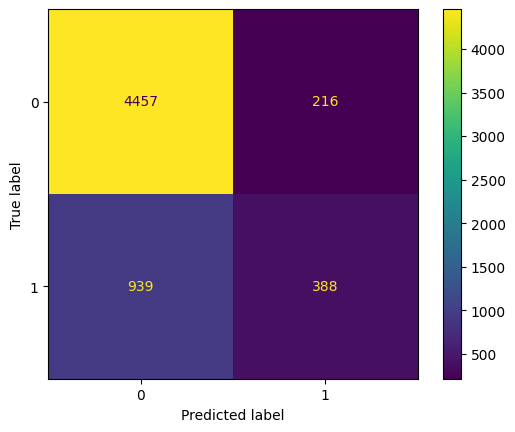

In [ ]:
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(cm)
display.plot()
plt.show()

The **baseline Logistic Regression** model achieved an **accuracy of 81%** and a **ROC-AUC of 0.744**, indicating a decent overall performance and good ranking ability in distinguishing defaulters from non-defaulters.

However, despite the high accuracy, the model performed **poorly in detecting the minority class** (**defaulters**), with a **recall of only 29%**, meaning **it missed a large portion of risky customers** (939 out of 1,327)

Precision for defaulters is relatively strong at **64%**, indicating that **when the model predicted default, it was often correct**.

In a **credit risk context**, this could be **problematic** because **failing to identify defaulters can lead to financial losses**, even if overall accuracy appears high.

**2. Applying class_weight to the Baseline Model**
---

**class_weight** is a parameter that adjusts how much the model **penalizes mistakes for each class during training**. In **imbalanced datasets**, **it increases the importance of the minority class so that misclassifying those samples has a larger impact on the loss function**. This helps the model pay more attention to rare but important cases, such as defaulters in credit risk prediction.



---


**NOTE:** balanced means that the model balances the influence of each class in the loss function.

In [ ]:
lr_cw_pipeline = Pipeline(
    steps = [
        ('preprocessing', preprocessor),
        ('model', LogisticRegression(class_weight='balanced', random_state=42))
    ]
)

In [ ]:
lr_cw_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical_scaling',
                                                  StandardScaler(),
                                                  ['LIMIT_BAL', 'AGE',
                                                   'AVG_BILL_AMT',
                                                   'MAX_BILL_AMT',
                                                   'AVG_PAY_AMT', 'MAX_PAY_AMT',
                                                   'AVG_PAY_BILL_RATIO',
                                                   'MIN_PAY_BILL_RATIO',
                                                   'MAX_PAY_DELAY',
                                                   'AVG_PAY_DELAY',
                                                   'RECENT_PAY_STAT',
                                                   'NUM_LATE_PAY']),
                                                 ('categorical_encoding',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SEX', 'EDUCATION',
                                                   'MARRIAGE'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [ ]:
y_pred_cw = lr_cw_pipeline.predict(x_test)
y_proba_cw = lr_cw_pipeline.predict_proba(x_test)[:, 1]

In [ ]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_cw))

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.78      0.83      4673
           1       0.44      0.60      0.51      1327

    accuracy                           0.74      6000
   macro avg       0.66      0.69      0.67      6000
weighted avg       0.78      0.74      0.76      6000



In [ ]:
print("ROC-AUC:")
print(roc_auc_score(y_test, y_proba_cw))

ROC-AUC:
0.7459887171103186


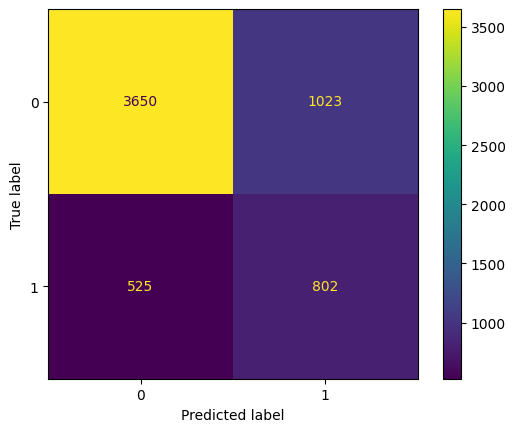

In [ ]:
cm = confusion_matrix(y_test, y_pred_cw)
display = ConfusionMatrixDisplay(cm)
display.plot()
plt.show()

After applying **class_weight='balanced'**, the Logistic Regression model becomes **more sensitive to the minority class** (**defaulters**). **Recall for defaulters** increases from **29%** to **60%**, **reducing missed risky customers from 939 to 525**, which is a major improvement in a credit risk context. However, this comes at the cost of **lower precision** (**from 64% to 44%**) and **reduced overall accuracy** (**from 81% to 74%**), as the model now **flags more safe customers as risky** (higher false positives).

The **ROC-AUC** remains almost **unchanged** (**0.746**), indicating that the model’s ranking ability did not improve. It only **shifts the decision boundary to prioritize detecting defaults to reduce the possibility of financial losses due to missed risky customers**.

**3. Compare Models**
---


Model: LR
              precision    recall  f1-score   support

           0       0.87      0.78      0.83      4673
           1       0.44      0.60      0.51      1327

    accuracy                           0.74      6000
   macro avg       0.66      0.69      0.67      6000
weighted avg       0.78      0.74      0.76      6000


ROC-AUC:  0.7459887171103186



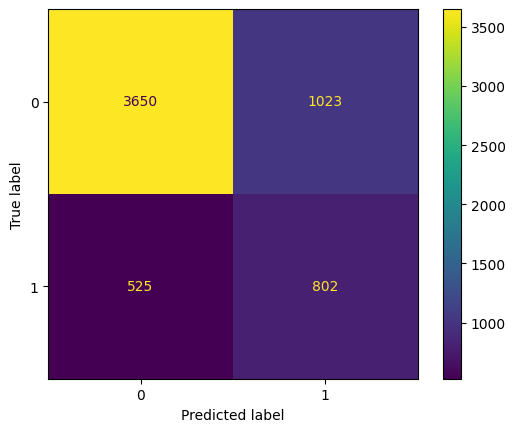


Model: DT
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      4673
           1       0.39      0.38      0.39      1327

    accuracy                           0.73      6000
   macro avg       0.61      0.61      0.61      6000
weighted avg       0.73      0.73      0.73      6000


ROC-AUC:  0.6063887189809631



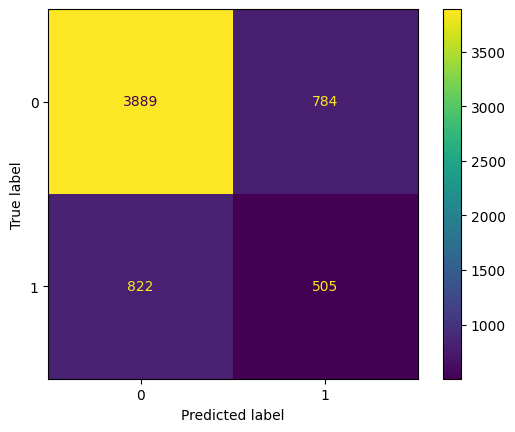


Model: RF
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.64      0.35      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000


ROC-AUC:  0.7626769633826158



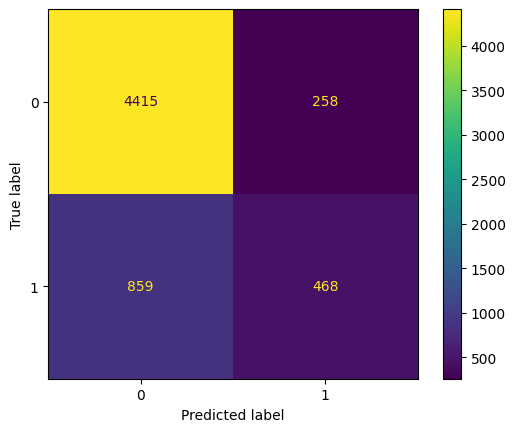

In [ ]:
models = {
    'LR' : LogisticRegression(class_weight='balanced', random_state=42),
    'DT' : DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'RF' : RandomForestClassifier(class_weight='balanced', random_state=42)
}

pipelines = {}

for name, model in models.items():
  pipeline = Pipeline(
      steps = [
          ('preprocessing', preprocessor),
          ('model', model)
      ]
  )

  pipeline.fit(x_train, y_train)

  y_pred = pipeline.predict(x_test)
  y_proba = pipeline.predict_proba(x_test)[:, 1]

  pipelines[name] = pipeline

  print("\n==============================")
  print("Model:", name)
  print(classification_report(y_test, y_pred))
  print("\nROC-AUC: ", roc_auc_score(y_test, y_proba))
  print("")

  cm = confusion_matrix(y_test, y_pred)
  display = ConfusionMatrixDisplay(cm)
  display.plot()
  plt.show()

  print("==============================")

Based on model comparison, **Random Forest** is selected as the final candidate model due to its **superior discriminative performance**. Although **Logistic Regression achieves higher recall at the default threshold (0.5)**, **Random Forest produces the highest ROC-AUC score (0.763)**, indicating stronger overall ranking ability in distinguishing defaulters from non-defaulters. Since ROC-AUC measures how well the model separates risky and safe customers independent of threshold, it is a more reliable indicator of model quality. Therefore, **Random Forest is chosen for further optimization**.

**4. Threshold Tuning (Random Forest)**
---

In **credit risk prediction**, **failing to detect a defaulter (false negative) is more costly than incorrectly flagging a safe customer (false positive)**. Therefore, the **model evaluation focuses on improving recall for the default class**.

Random Forest demonstrates **strong ranking power (high ROC-AUC)**, meaning it **effectively distinguish defaulters from non-defaulters**. Therefore, adjusting the **classification threshold** allows better alignment with **business objectives by controlling the trade-off between precision and recall**. Lowering the threshold increases detection of defaulters while maintaining acceptable precision, making the model more suitable for risk-sensitive credit decisions.

In [ ]:
rf_pipeline = pipelines['RF']
rf_model = rf_pipeline.named_steps['model']
rf_preprocessor = rf_pipeline.named_steps['preprocessing']
print(rf_model)
print(rf_preprocessor)

RandomForestClassifier(class_weight='balanced', random_state=42)
ColumnTransformer(transformers=[('numerical_scaling', StandardScaler(),
                                 ['LIMIT_BAL', 'AGE', 'AVG_BILL_AMT',
                                  'MAX_BILL_AMT', 'AVG_PAY_AMT', 'MAX_PAY_AMT',
                                  'AVG_PAY_BILL_RATIO', 'MIN_PAY_BILL_RATIO',
                                  'MAX_PAY_DELAY', 'AVG_PAY_DELAY',
                                  'RECENT_PAY_STAT', 'NUM_LATE_PAY']),
                                ('categorical_encoding',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['SEX', 'EDUCATION', 'MARRIAGE'])])


In [ ]:
y_proba_rf = rf_pipeline.predict_proba(x_test)[:, 1]


Classification Report for Threshold = 0.2:
              precision    recall  f1-score   support

           0       0.89      0.71      0.79      4673
           1       0.41      0.69      0.51      1327

    accuracy                           0.71      6000
   macro avg       0.65      0.70      0.65      6000
weighted avg       0.78      0.71      0.73      6000


ROC-AUC:  0.7626769633826158



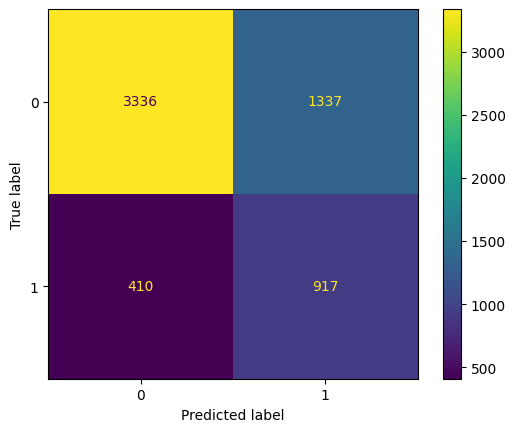


Classification Report for Threshold = 0.25:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4673
           1       0.46      0.62      0.53      1327

    accuracy                           0.75      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.75      0.77      6000


ROC-AUC:  0.7626769633826158



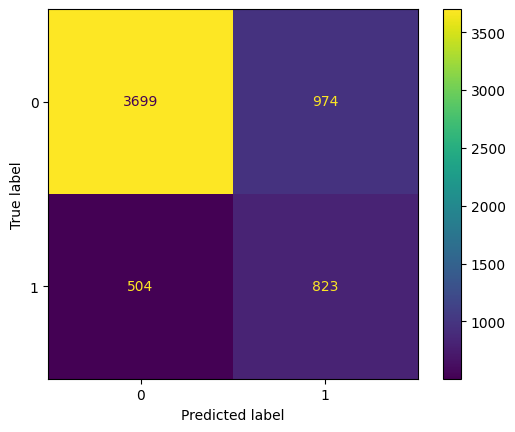


Classification Report for Threshold = 0.3:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4673
           1       0.50      0.55      0.52      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000


ROC-AUC:  0.7626769633826158



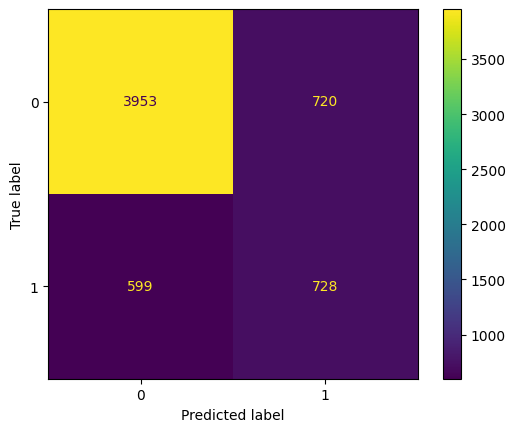


Classification Report for Threshold = 0.35:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      4673
           1       0.54      0.49      0.51      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.68      0.69      6000
weighted avg       0.79      0.79      0.79      6000


ROC-AUC:  0.7626769633826158



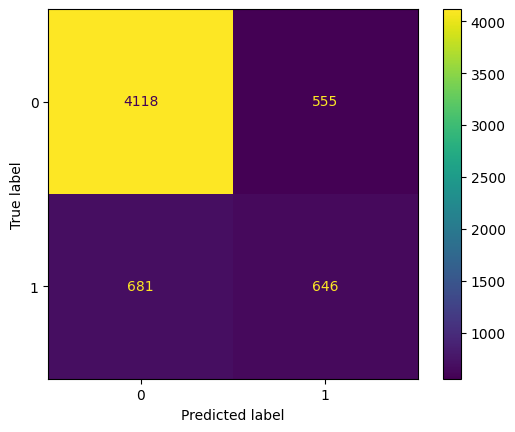


Classification Report for Threshold = 0.39999999999999997:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      4673
           1       0.58      0.44      0.50      1327

    accuracy                           0.81      6000
   macro avg       0.71      0.67      0.69      6000
weighted avg       0.79      0.81      0.80      6000


ROC-AUC:  0.7626769633826158



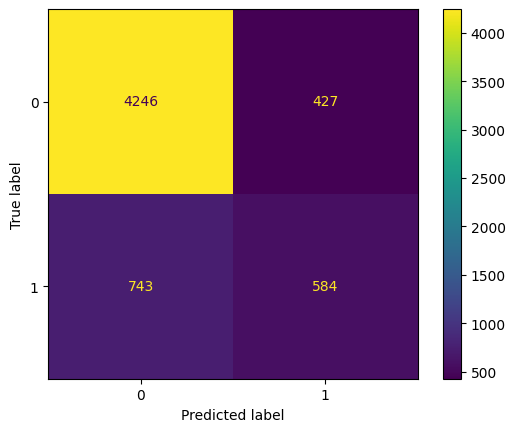


Classification Report for Threshold = 0.44999999999999996:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      4673
           1       0.61      0.41      0.49      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.67      0.69      6000
weighted avg       0.80      0.81      0.80      6000


ROC-AUC:  0.7626769633826158



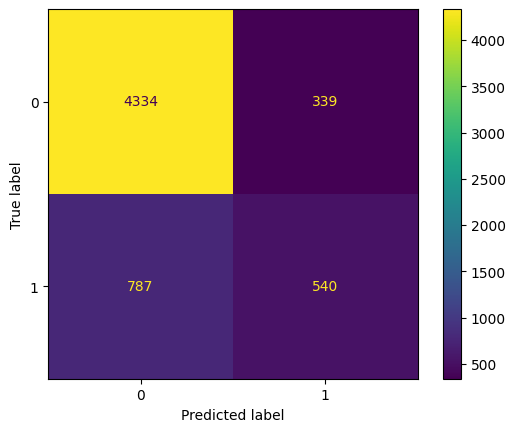


Classification Report for Threshold = 0.49999999999999994:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.64      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.79      0.81      0.79      6000


ROC-AUC:  0.7626769633826158



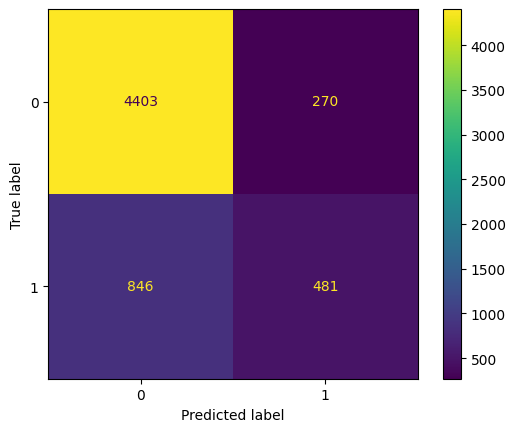


Classification Report for Threshold = 0.5499999999999999:
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4673
           1       0.67      0.32      0.43      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.64      0.66      6000
weighted avg       0.80      0.81      0.79      6000


ROC-AUC:  0.7626769633826158



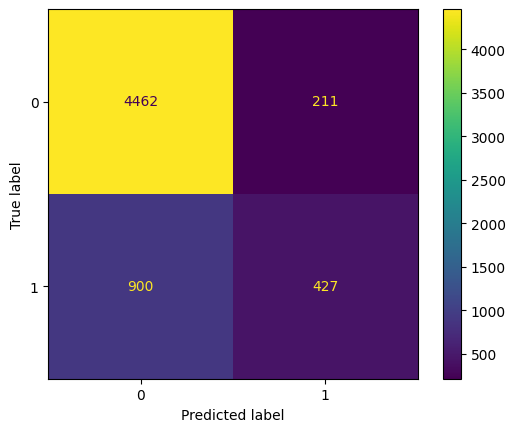

In [ ]:
threshold = np.arange(0.2, 0.6, 0.05)

for t in threshold:
  y_pred_rf = (y_proba_rf >= t).astype(int)
  print(f'\nClassification Report for Threshold = {t}:')
  print(classification_report(y_test, y_pred_rf))
  print("\nROC-AUC: ", roc_auc_score(y_test, y_proba_rf))

  print("")

  cm = confusion_matrix(y_test, y_pred_rf)
  display = ConfusionMatrixDisplay(cm)
  display.plot()
  plt.show()

The final classification threshold is set to **0.25** after evaluating the precision–recall trade-off across multiple threshold values. At the **default threshold of 0.5**, **Random Forest achieves high precision but relatively low recall (0.35)**, meaning **many defaulters are not detected**. By **lowering the threshold to 0.25**, **recall improves significantly to 0.62**, while **precision remains acceptable at 0.46**. **This threshold provides a more balanced trade-off and better aligns with the credit risk objective of minimizing missed defaulters, where the cost of approving a risky customer is typically higher than rejecting a safe one**. Therefore, **0.25 is selected as the optimal decision boundary**.

# **SHAP (MODEL INTERPRETABILITY)**

In [ ]:
x_test_processed = rf_pipeline.named_steps['preprocessing'].transform(x_test)

In [ ]:
# Take random 500 samples
idx = np.random.choice(x_test_processed.shape[0], 500, replace=False)
x_sample = x_test_processed[idx]

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(x_sample)
shap_values_class1 = shap_values[:, :, 1]

In [ ]:
feature_names = rf_preprocessor.get_feature_names_out()

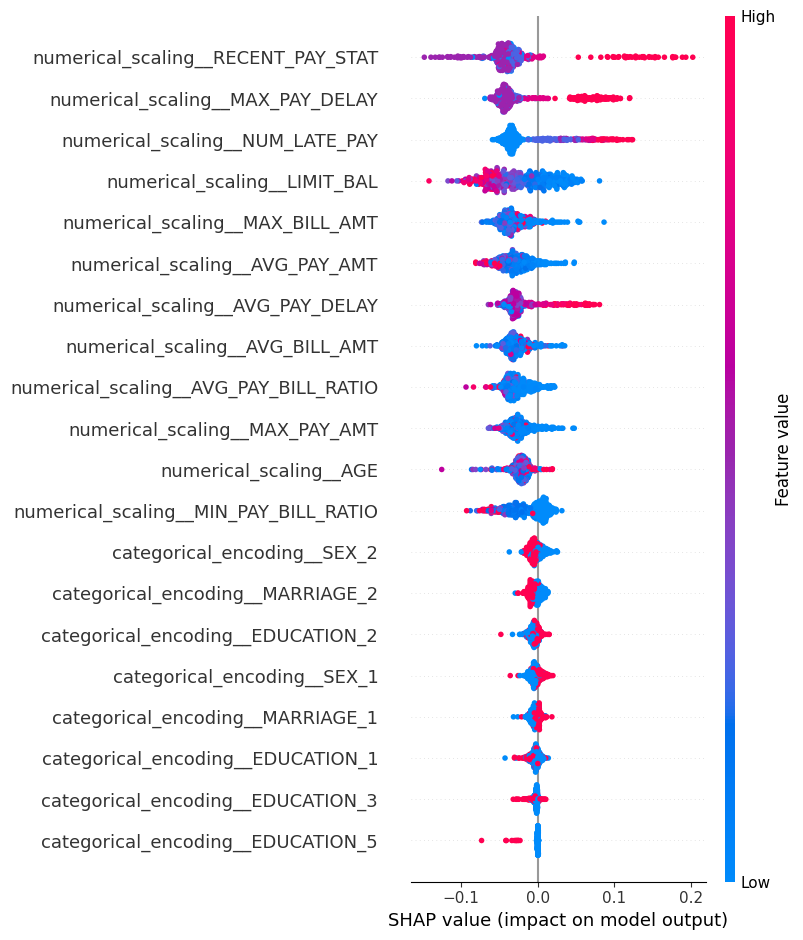

In [ ]:
shap.summary_plot(
    shap_values_class1,
    x_sample,
    feature_names=feature_names
)

The **global SHAP summary plot** shows that the **model’s predictions are mainly driven by repayment behavior variables rather than demographic features**. Indicators such as **recent payment status**, **maximum payment delay**, and **number of late payments** have the largest impact on default probability, confirming that **past payment behavior is the strongest determinant of credit risk**. Demographic variables contribute relatively little, suggesting that the model relies primarily on financial behavior patterns to assess risk.

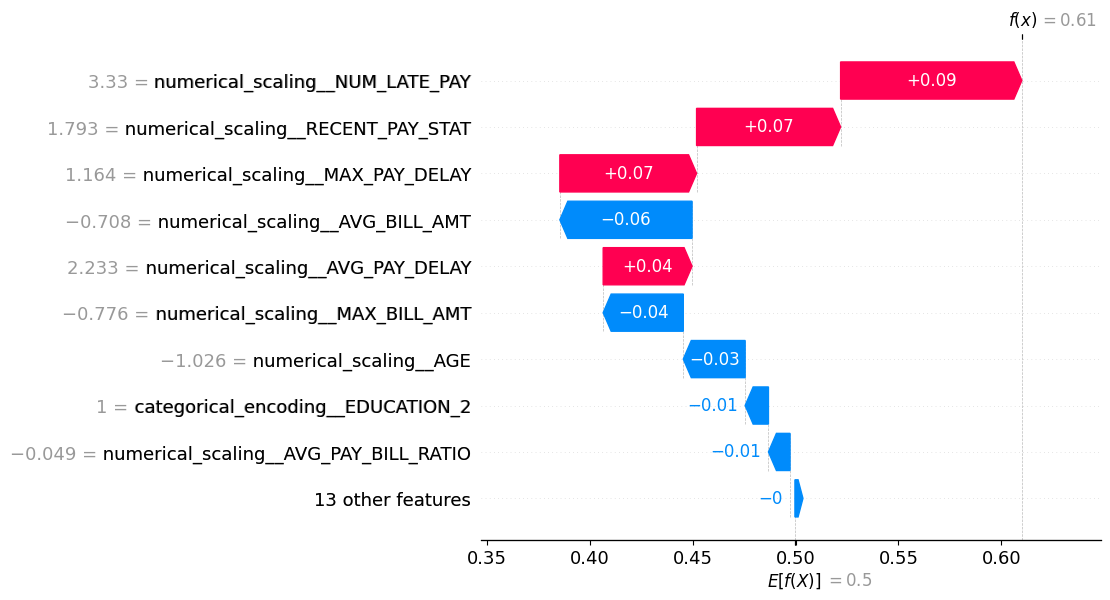

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_class1[0],
        base_values=explainer.expected_value[1],
        data=x_sample[0],
        feature_names=feature_names
    )
)

The **local SHAP waterfall plot** explains **why one specific customer was predicted as high risk**. It shows **how each feature either increases or decreases the default probability**. **For this customer, several payment-related factors, such as late payments and recent delays, strongly push the prediction higher**. Although some features slightly reduce the risk, they are not strong enough to offset the negative payment history. In simple terms, **the customer is classified as risky mainly because of repeated and recent payment delays**.

# **CONCLUSION**

This project developed a machine learning model to predict **credit default risk using customer financial and repayment behavior data**. Several models were evaluated, including **Logistic Regression**, **Decision Tree**, and **Random Forest**, using **metrics** such as **precision**, **recall**, **F1-score**, and **ROC-AUC**. Among the tested models, **Random Forest demonstrated the best overall performance, particularly in terms of ROC-AUC and its ability to capture complex relationships within the data**.

To **better address the class imbalance and reduce the risk of missing potential defaulters**, **threshold tuning was applied** instead of using the default classification threshold of 0.5. By **adjusting the decision threshold to 0.25**, **the model achieved a better balance between precision and recall for the default class**, **improving its ability to identify high-risk customers** while maintaining reasonable overall performance.

Model interpretability was further explored using **SHAP** analysis. The **global explanation** showed that **repayment behavior features**, such as recent payment status, maximum payment delay, and number of late payments, were **the most influential factors in predicting default risk**. The **local explanation** confirmed that **customers with frequent and recent payment delays were more likely to be classified as high risk**. These findings indicate that **the model relies primarily on meaningful financial behavior patterns rather than demographic characteristics**.

Overall, the results demonstrate that machine learning models can effectively support credit risk assessment by identifying key behavioral indicators of default. By **combining model evaluation**, **threshold optimization**, and **interpretability techniques**, **the final model provides both strong predictive performance and transparent insights that can assist financial institutions in making more informed lending decisions**.